In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

In [13]:
# Загрузка сырых данных
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Размер исходных данных: {df.shape}')

# Преобразование TotalCharges в число, пропуски → 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Удаление customerID (бесполезный признак)
df.drop('customerID', axis=1, inplace=True)

# Сохранение очищенной версии
df.to_csv('../data/telco_cleaned.csv', index=False)
print("Очищенные данные сохранены в data/telco_cleaned.csv")
print(f"Пропусков после очистки: {df.isnull().sum().sum()}")

Размер исходных данных: (7043, 21)
Очищенные данные сохранены в data/telco_cleaned.csv
Пропусков после очистки: 0


Доля оттока: 26.5%


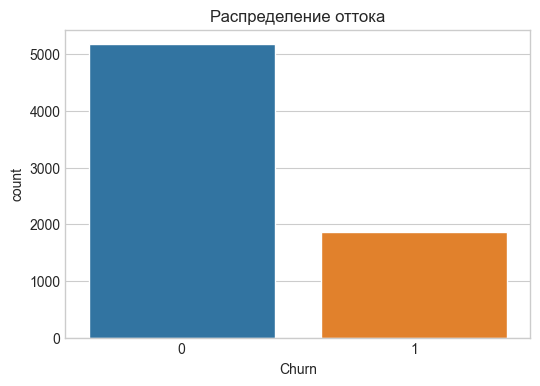

<Figure size 800x500 with 0 Axes>

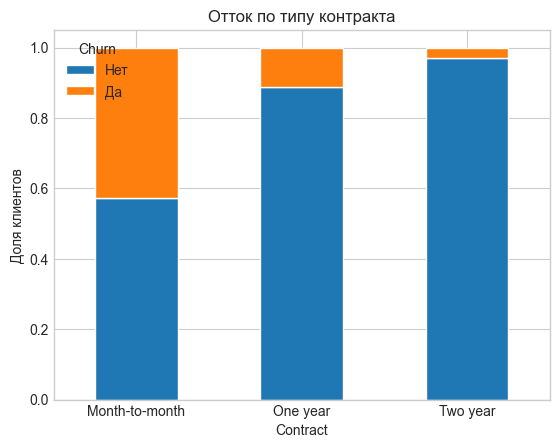

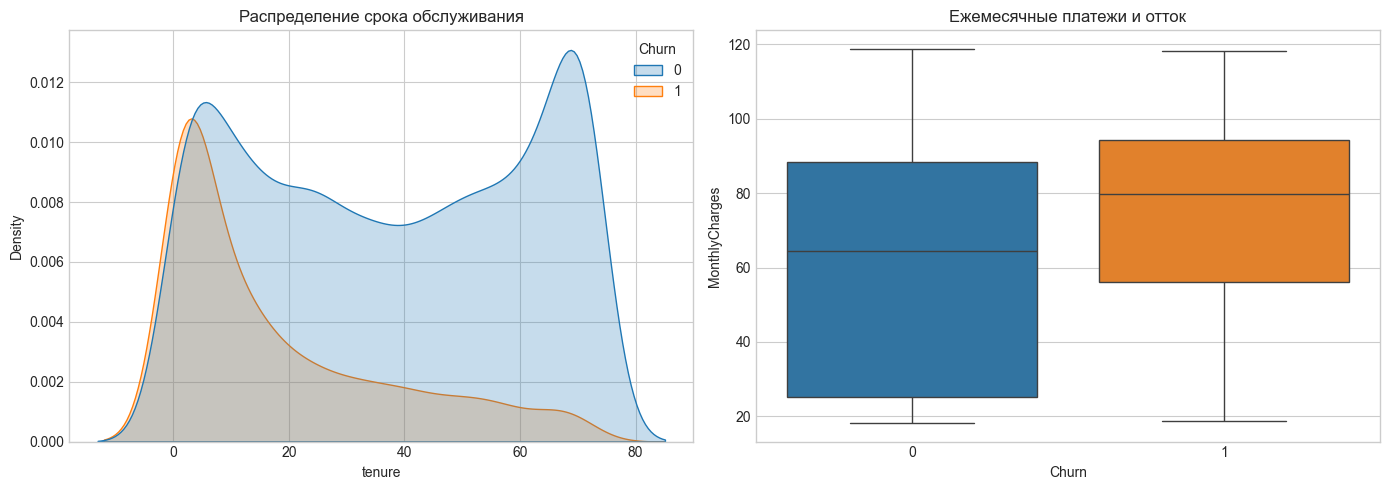

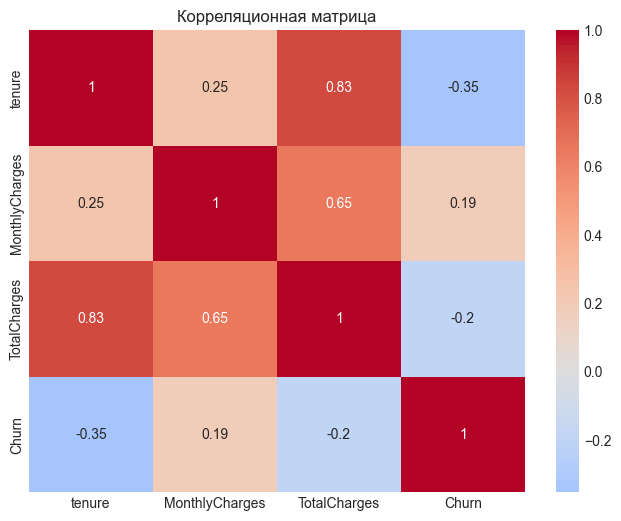

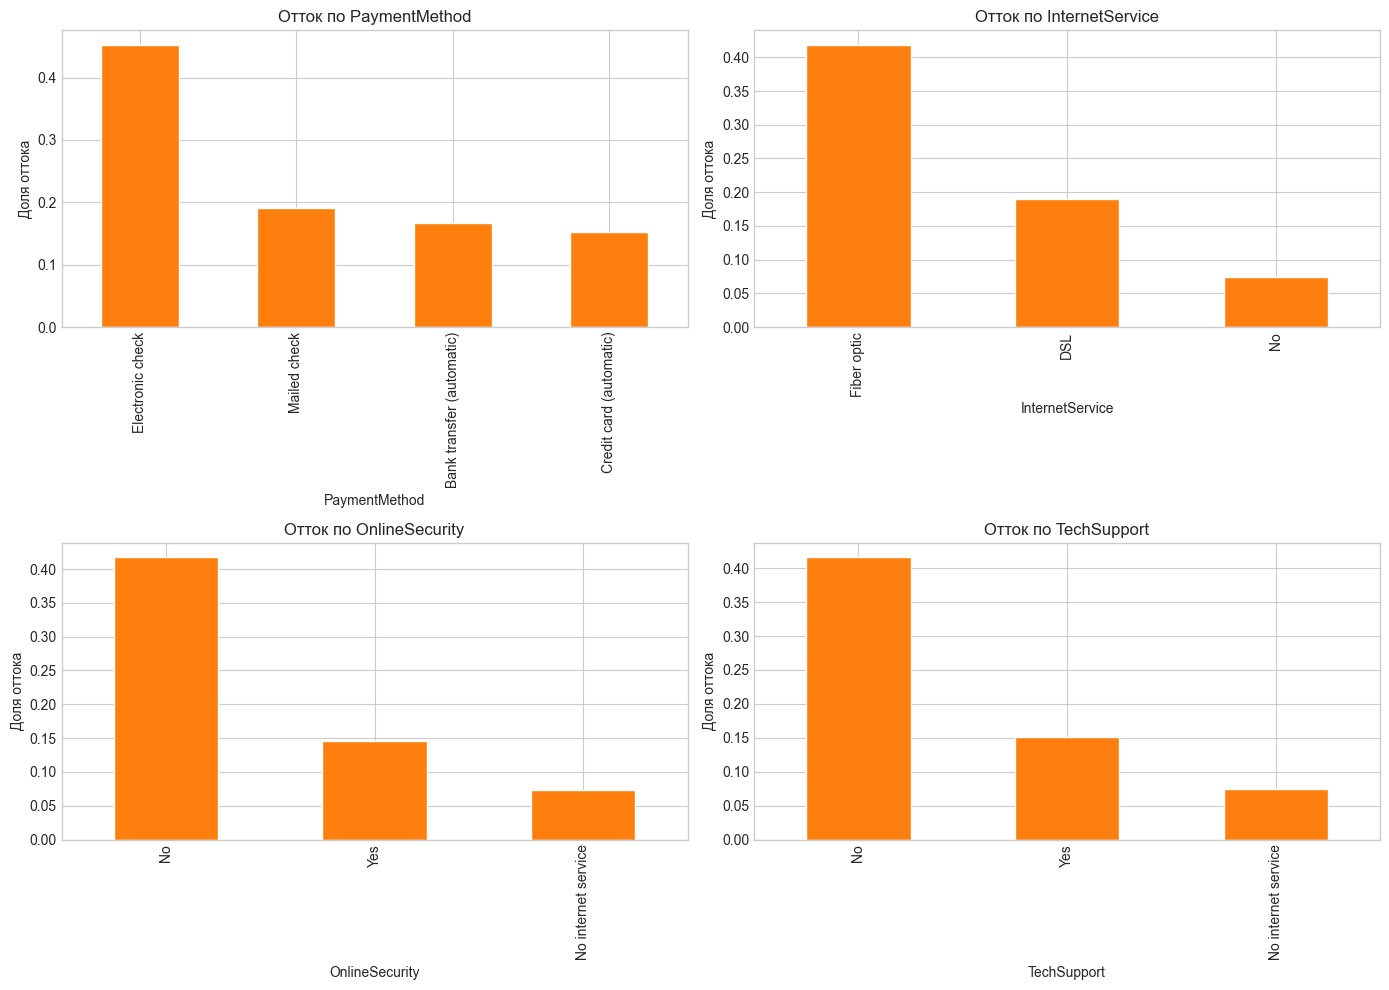

Ключевые выводы EDA:
- Дисбаланс: 26% оттока
- Помесячный контракт → высокий отток (~45%)
- Низкий tenure (<12 мес) → высокий отток
- Высокие MonthlyCharges → выше риск
- Электронные чеки, отсутствие OnlineSecurity/TechSupport увеличивают отток


In [14]:
# Преобразуем Churn в число для удобства расчётов
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
plt.style.use('seaborn-v0_8-whitegrid')
colors = {0: '#1f77b4', 1: '#ff7f0e'}

print(f"Доля оттока: {df['Churn'].mean():.1%}")

# 1. Распределение оттока
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', hue='Churn', palette=colors, legend=False)
plt.title('Распределение оттока')
plt.show()

# 2. Отток по типу контракта
plt.figure(figsize=(8,5))
churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
churn_by_contract.plot(kind='bar', stacked=True, color=[colors[0], colors[1]])
plt.title('Отток по типу контракта')
plt.ylabel('Доля клиентов')
plt.legend(title='Churn', labels=['Нет', 'Да'])
plt.xticks(rotation=0)
plt.show()

# 3. Tenure и MonthlyCharges
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, palette=colors, ax=axes[0])
axes[0].set_title('Распределение срока обслуживания')
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette=colors, legend=False, ax=axes[1])
axes[1].set_title('Ежемесячные платежи и отток')
plt.tight_layout()
plt.show()

# 4. Корреляции числовых признаков
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show()

# 5. Категориальные признаки с высоким оттоком
cat_features = ['PaymentMethod', 'InternetService', 'OnlineSecurity', 'TechSupport']
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for ax, col in zip(axes.flat, cat_features):
    rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#ff7f0e')
    ax.set_title(f'Отток по {col}')
    ax.set_ylabel('Доля оттока')
plt.tight_layout()
plt.show()

print("Ключевые выводы EDA:")
print("- Дисбаланс: 26% оттока")
print("- Помесячный контракт → высокий отток (~45%)")
print("- Низкий tenure (<12 мес) → высокий отток")
print("- Высокие MonthlyCharges → выше риск")
print("- Электронные чеки, отсутствие OnlineSecurity/TechSupport увеличивают отток")

In [15]:
# Биннинг tenure
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72],
                            labels=['0-1y', '1-2y', '2-3y', '3-4y', '4-5y', '5-6y'])

# Количество дополнительных услуг
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['TotalServices'] = df[service_cols].apply(lambda x: (x != 'No').sum(), axis=1)

# Взаимодействие месячных платежей и срока обслуживания
df['Charges_Tenure_Interaction'] = df['MonthlyCharges'] * df['tenure']

In [16]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# Определение категориальных и числовых колонок
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Категориальные: {categorical_cols}")
print(f"Числовые: {numeric_cols}")

Train: (5634, 22), Test: (1409, 22)
Категориальные: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
Числовые: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'Charges_Tenure_Interaction']


C:\Users\ksolo\AppData\Local\Temp\ipykernel_19664\586995748.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


In [17]:
categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer([
    ('categorical', categorical_pipeline, categorical_cols),
    ('numeric', numeric_pipeline, numeric_cols)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
print(f'Размер после обработки: {X_train_proc.shape}')

Размер после обработки: (5634, 38)


In [18]:
joblib.dump(preprocessor, '../artifacts/preprocessor.joblib')
np.save('../artifacts/X_train_preprocessed.npy', X_train_proc)
np.save('../artifacts/X_test_preprocessed.npy', X_test_proc)
np.save('../artifacts/y_train.npy', y_train)
np.save('../artifacts/y_test.npy', y_test)

print("Артефакты сохранены в папку artifacts/")
print("- preprocessor.joblib")
print("- X_train_preprocessed.npy, X_test_preprocessed.npy")
print("- y_train.npy, y_test.npy")

Артефакты сохранены в папку artifacts/
- preprocessor.joblib
- X_train_preprocessed.npy, X_test_preprocessed.npy
- y_train.npy, y_test.npy
